In [2]:
!pip install econml

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib import style
style.use("ggplot")

import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
from sklearn.model_selection import train_test_split

from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML





[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
data = pd.read_csv("E:\\UofT\\03_ML\\Project\\project_file\\data\\clean_data.csv")

data["select"] = data["select"].map({"control": 0, "selected": 1}).astype(int)
data = pd.get_dummies(data, columns=["city", "educ_lb"], drop_first = False)
data.columns = data.columns.str.replace('.', '_', regex=False)

train, test = train_test_split(
    data,
    test_size=0.3,        # 30% validation, 70% training
    random_state=0,      # ensures reproducibility
    shuffle=True
)

In [22]:
!pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_predict

X_cols = [
    "age_lb", "salary_04", "empl_04", 'dwomen', 'dmarried_lb',
    "city_1_0", "city_2_0", "city_3_0", "city_4_0", "city_5_0", "city_6_0",
    "educ_lb_0_0","educ_lb_2_0","educ_lb_3_0","educ_lb_4_0","educ_lb_5_0",
    "educ_lb_6_0","educ_lb_7_0","educ_lb_8_0","educ_lb_9_0","educ_lb_10_0",
    "educ_lb_12_0","educ_lb_13_0","educ_lb_14_0","educ_lb_16_0"
]



y_train = train["empl_06"]
T_train = train["select"]
X_train = train[X_cols]

y_test = test["empl_06"]
T_test = test["select"]
X_test = test[X_cols]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from lightgbm import LGBMClassifier, LGBMRegressor

est_linear = LinearDML(
    model_y=LGBMRegressor(max_depth=5, verbose=-1),
    model_t=LGBMClassifier(max_depth=5, verbose=-1),
    discrete_treatment=True,
    featurizer=None,
    cv=5,
    random_state=123
)


est_linear.fit(Y=y_train, T=T_train, X=X_train)


c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: Use

In [25]:
# Test-set CATEs
cate_linear = est_linear.effect(X_test)

# Test-set ATE
ate_linear = cate_linear.mean()
se_linear = cate_linear.std(ddof=1) / np.sqrt(len(cate_linear))
ci_linear = (ate_linear - 1.96 * se_linear, ate_linear + 1.96 * se_linear)

print("\n===== LINEAR DML =====")
print("ATE (test-set):", ate_linear)
print("95% CI:", ci_linear)


===== LINEAR DML =====
ATE (test-set): 0.022319509510447616
95% CI: (np.float64(0.014934870784541743), np.float64(0.02970414823635349))


In [27]:


# Test-set CATE
cate_test_linear = est.effect(X_test)

test_pred = test.copy()
test_pred["cate_hat_linear"] = cate_test_linear


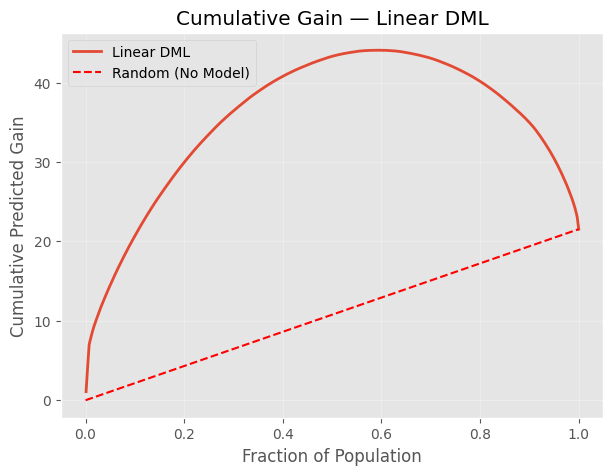

In [28]:
df_gain_linear = test_pred.copy()
df_gain_linear = df_gain_linear.sort_values("cate_hat_linear", ascending=False).reset_index(drop=True)

n = len(df_gain_linear)
df_gain_linear["fraction"] = (np.arange(n) + 1) / n
df_gain_linear["cum_uplift"] = df_gain_linear["cate_hat_linear"].cumsum()
total_uplift_linear = df_gain_linear["cum_uplift"].iloc[-1]

plt.figure(figsize=(7,5))
plt.plot(df_gain_linear["fraction"], df_gain_linear["cum_uplift"],
         label="Linear DML", linewidth=2)

plt.plot([0,1], [0, total_uplift_linear], linestyle="--", color="red",
         label="Random (No Model)")

plt.title("Cumulative Gain — Linear DML")
plt.xlabel("Fraction of Population")
plt.ylabel("Cumulative Predicted Gain")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [29]:
forest = CausalForestDML(
    n_estimators=2000,
    min_samples_leaf=10,
    max_depth=None,
    model_t=LGBMRegressor(max_depth=4),
    model_y=LGBMRegressor(max_depth=4),
    verbose=0,
    random_state=123
)


forest.fit(Y=y_train, T=T_train, X=X_train)


c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\narde\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserW

In [32]:
# Test-set CATEs
cate_forest = forest.effect(X_test)

# Test-set ATE
ate_forest = cate_forest.mean()
se_forest = cate_forest.std(ddof=1) / np.sqrt(len(cate_forest))
ci_forest = (ate_forest - 1.96 * se_forest, ate_forest + 1.96 * se_forest)

print("\n===== CAUSAL FOREST =====")
print("ATE (test-set):", ate_forest)
print("95% CI:", ci_forest)


===== CAUSAL FOREST =====
ATE (test-set): 0.02239824888479678
95% CI: (np.float64(0.018756215892760282), np.float64(0.026040281876833278))


In [31]:
def build_gain_curve(df, cate_col):
    df = df.copy()
    df["cate_hat"] = df[cate_col]
    df = df.sort_values("cate_hat", ascending=False).reset_index(drop=True)

    n = len(df)
    df["fraction"] = (np.arange(n) + 1) / n
    df["cum_uplift"] = df["cate_hat"].cumsum()

    return df


test_linear = test.copy()
test_linear["cate_linear"] = cate_linear
df_gain_linear = build_gain_curve(test_linear, "cate_linear")

test_forest = test.copy()
test_forest["cate_forest"] = cate_forest
df_gain_forest = build_gain_curve(test_forest, "cate_forest")

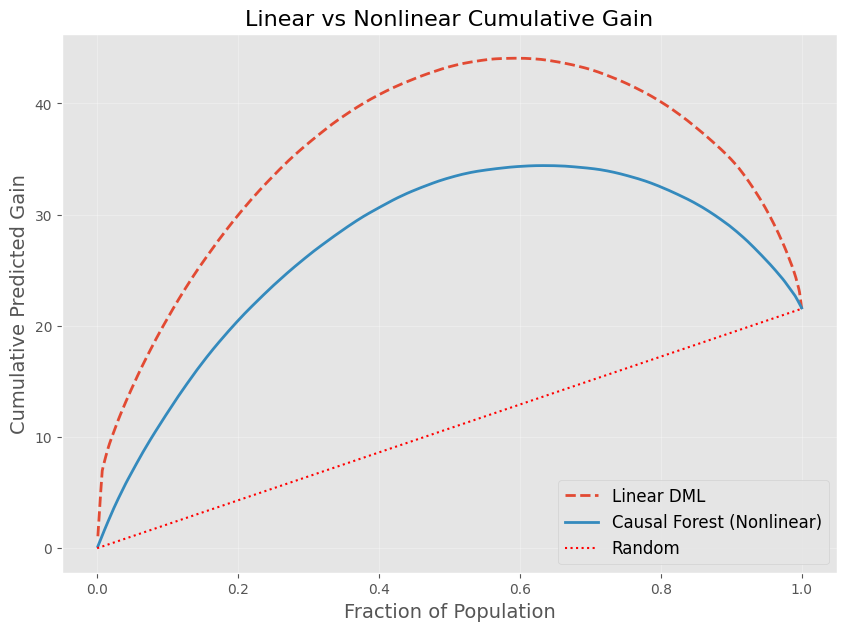

In [33]:
plt.figure(figsize=(10, 7))

plt.plot(df_gain_linear["fraction"], df_gain_linear["cum_uplift"],
         label="Linear DML", linestyle="--", linewidth=2)

plt.plot(df_gain_forest["fraction"], df_gain_forest["cum_uplift"],
         label="Causal Forest (Nonlinear)", linewidth=2)

# Random baseline
total_uplift = df_gain_linear["cum_uplift"].iloc[-1]
plt.plot([0, 1], [0, total_uplift], "r:", label="Random")

plt.title("Linear vs Nonlinear Cumulative Gain", fontsize=16)
plt.xlabel("Fraction of Population", fontsize=14)
plt.ylabel("Cumulative Predicted Gain", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [34]:
# X, forest, X_cols, test already defined

# Build X_test as DataFrame to keep column names
X_test = test[X_cols]

# CATEs for everyone in test set
cate_test_cf = forest.effect(X_test)

test_cf = test.copy()
test_cf["cate_hat_forest"] = cate_test_cf

# Masks
mask_w = test_cf["dwomen"] == 1
mask_m = test_cf["dwomen"] == 0

# Group-specific ATEs (average CATE in each group)
ate_women = test_cf.loc[mask_w, "cate_hat_forest"].mean()
ate_men   = test_cf.loc[mask_m, "cate_hat_forest"].mean()

se_women = test_cf.loc[mask_w, "cate_hat_forest"].std(ddof=1) / np.sqrt(mask_w.sum())
se_men   = test_cf.loc[mask_m, "cate_hat_forest"].std(ddof=1) / np.sqrt(mask_m.sum())

print("ATE (women):", ate_women, "  95% CI:", (ate_women - 1.96*se_women, ate_women + 1.96*se_women))
print("ATE (men):  ", ate_men,   "  95% CI:", (ate_men   - 1.96*se_men,   ate_men   + 1.96*se_men))

# Difference in effects (women − men)
diff = ate_women - ate_men
se_diff = np.sqrt(se_women**2 + se_men**2)
print("Difference (women - men):", diff, "  95% CI:", (diff - 1.96*se_diff, diff + 1.96*se_diff))


ATE (women): 0.04023160479086712   95% CI: (np.float64(0.03543384601018899), np.float64(0.04502936357154525))
ATE (men):   0.0019037908724754103   95% CI: (np.float64(-0.0030153705137618515), np.float64(0.006822952258712672))
Difference (women - men): 0.03832781391839171   95% CI: (np.float64(0.03145637752842041), np.float64(0.04519925030836301))


In [35]:
X_test = test[X_cols].copy()

# Make two copies: one with dwomen = 1, one with dwomen = 0
X_w = X_test.copy()
X_m = X_test.copy()
X_w["dwomen"] = 1
X_m["dwomen"] = 0

tau_w = forest.effect(X_w)
tau_m = forest.effect(X_m)

delta_gender = tau_w - tau_m   # effect of being a woman on the CATE

# Average marginal effect of dwomen
ame_dwomen = delta_gender.mean()
se_ame = delta_gender.std(ddof=1) / np.sqrt(len(delta_gender))

print("Average marginal effect of dwomen on CATE:", ame_dwomen)
print("95% CI:", (ame_dwomen - 1.96*se_ame, ame_dwomen + 1.96*se_ame))


Average marginal effect of dwomen on CATE: 0.02672653284997365
95% CI: (np.float64(0.023397693320845927), np.float64(0.030055372379101376))
